# Blueteam Monitor — Phase 2: ML Training (v3)
### Strategi: Semi-supervised — train HANYA data normal, test pada campuran
### Dataset: CICIDS 2017 | Model: Isolation Forest


In [1]:
# ─── CELL 1: Import ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json, warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

DATASET_PATH = os.path.expanduser('~/blueteam-monitor/ml-engine/datasets/cicids')
MODEL_PATH   = os.path.expanduser('~/blueteam-monitor/ml-engine/models')
os.makedirs(MODEL_PATH, exist_ok=True)
print('✅ Ready')

✅ Ready


In [2]:
# ─── CELL 2: Load & Clean ─────────────────────────────────────
files = {
    'monday_normal'  : 'Monday-WorkingHours.pcap_ISCX.csv',
    'tuesday_brute'  : 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'friday_portscan': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'friday_ddos'    : 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
}
dfs = {}
for key, filename in files.items():
    path = os.path.join(DATASET_PATH, filename)
    dfs[key] = pd.read_csv(path, low_memory=False)
    print(f'[{key}] {dfs[key].shape[0]:,} rows')

df_all = pd.concat(dfs.values(), ignore_index=True)
df_all.columns = df_all.columns.str.strip()

# Cleaning
df_clean = df_all.drop_duplicates()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean = df_clean.copy()
df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()
df_clean['is_attack'] = (df_clean['Label'] != 'BENIGN').astype(int)

print(f'\nSetelah cleaning: {df_clean.shape[0]:,} rows')
print(f'BENIGN : {(df_clean["is_attack"]==0).sum():,}')
print(f'ATTACK : {(df_clean["is_attack"]==1).sum():,}')

[monday_normal] 529,918 rows
[tuesday_brute] 445,909 rows
[friday_portscan] 286,467 rows
[friday_ddos] 225,745 rows

Setelah cleaning: 1,354,703 rows
BENIGN : 1,126,845
ATTACK : 227,858


In [3]:
# ─── CELL 3: Feature Selection ────────────────────────────────
SELECTED_FEATURES = [
    'Destination Port', 'Flow Duration',
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Fwd PSH Flags', 'SYN Flag Count', 'RST Flag Count',
    'ACK Flag Count', 'PSH Flag Count',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Packet Length Mean', 'Packet Length Std',
]
available = [f for f in SELECTED_FEATURES if f in df_clean.columns]
print(f'Features: {len(available)}/25 tersedia')

Features: 25/25 tersedia


In [4]:
# ─── CELL 4: Split Strategy (KUNCI PERBAIKAN) ────────────────
#
# Strategi BENAR untuk Isolation Forest:
#   TRAIN  → 80% data NORMAL saja (model belajar pola normal)
#   TEST   → 20% data NORMAL + SEMUA data ATTACK (evaluasi deteksi)
#
# Mengapa? Isolation Forest adalah anomaly detector:
#   - Dia tidak pernah 'melihat' serangan saat training
#   - Saat test, dia menilai: apakah ini menyimpang dari normal?

df_normal = df_clean[df_clean['is_attack'] == 0]
df_attack = df_clean[df_clean['is_attack'] == 1]

# Split data normal: 80% train, 20% test
normal_train, normal_test = train_test_split(
    df_normal, test_size=0.2, random_state=42
)

# Ambil sample attack untuk test (max 50k supaya tidak terlalu berat)
attack_test = df_attack.sample(n=min(50000, len(df_attack)), random_state=42)

# Training set: hanya data normal
X_train = normal_train[available]
y_train = normal_train['is_attack']  # semua 0

# Test set: normal + attack dicampur
df_test_combined = pd.concat([normal_test, attack_test]).sample(frac=1, random_state=42)
X_test = df_test_combined[available]
y_test = df_test_combined['is_attack']

print(f'TRAIN (normal only) : {len(X_train):,} samples')
print(f'TEST  (mixed)       : {len(X_test):,} samples')
print(f'  - Normal : {(y_test==0).sum():,}')
print(f'  - Attack : {(y_test==1).sum():,}')
print(f'\n✅ Strategi semi-supervised siap')
print('   Model akan belajar dari data NORMAL saja')

TRAIN (normal only) : 901,476 samples
TEST  (mixed)       : 275,369 samples
  - Normal : 225,369
  - Attack : 50,000

✅ Strategi semi-supervised siap
   Model akan belajar dari data NORMAL saja


In [5]:
# ─── CELL 5: Normalisasi ──────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ StandardScaler fitted pada data normal')

✅ StandardScaler fitted pada data normal


In [6]:
# ─── CELL 6: Training Isolation Forest ───────────────────────
# contamination = perkiraan % anomali di data NYATA (bukan train set)
# Untuk production monitoring, anomali biasanya < 5%
# Kita set 0.1 (10%) sebagai perkiraan konservatif
CONTAMINATION = 0.1

print(f'Contamination : {CONTAMINATION} (10% perkiraan anomali)')
print('Training... (estimasi 60-120 detik)\n')

iso_forest = IsolationForest(
    n_estimators   = 300,
    contamination  = CONTAMINATION,
    max_samples    = 'auto',
    max_features   = 1.0,
    bootstrap      = False,
    random_state   = 42,
    n_jobs         = -1,
    verbose        = 1,
)
iso_forest.fit(X_train_scaled)
print('\n✅ Training selesai!')

Contamination : 0.1 (10% perkiraan anomali)
Training... (estimasi 60-120 detik)



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.8s remaining:    4.1s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    4.1s



✅ Training selesai!


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    6.2s finished


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.9s finished


Default threshold (0)  : F1 = 40.49%
Best threshold (0.0892) : F1 = 46.28%


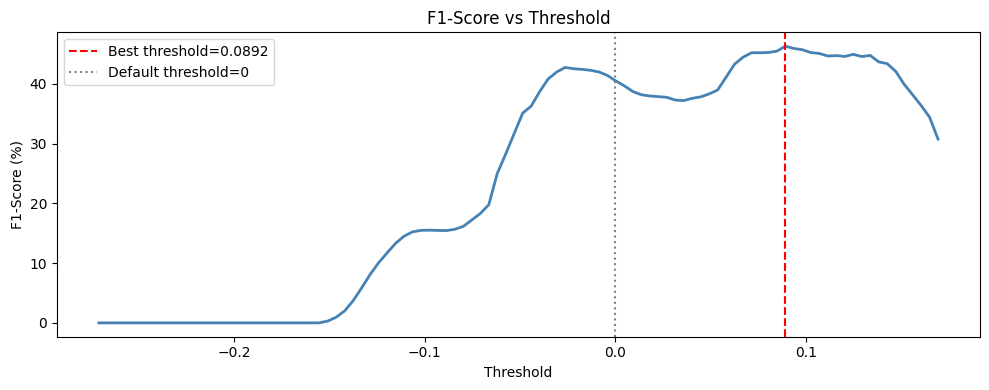

✅ Saved: threshold_tuning.png


In [7]:
# ─── CELL 7: Prediksi & Threshold Tuning ─────────────────────
# Isolation Forest output: anomaly score (makin negatif = makin anomali)
# Default threshold = 0, tapi kita bisa tune untuk hasil lebih baik

anomaly_scores = iso_forest.decision_function(X_test_scaled)

# Coba beberapa threshold dan lihat F1-score nya
thresholds = np.linspace(anomaly_scores.min(), anomaly_scores.max(), 100)
f1_scores  = []
for t in thresholds:
    pred = (anomaly_scores < t).astype(int)
    f1_scores.append(f1_score(y_test, pred, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f'Default threshold (0)  : F1 = {f1_score(y_test, (anomaly_scores < 0).astype(int))*100:.2f}%')
print(f'Best threshold ({best_threshold:.4f}) : F1 = {best_f1*100:.2f}%')

# Plot threshold vs F1
plt.figure(figsize=(10, 4))
plt.plot(thresholds, [s*100 for s in f1_scores], color='steelblue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.4f}')
plt.axvline(x=0, color='gray', linestyle=':', label='Default threshold=0')
plt.xlabel('Threshold')
plt.ylabel('F1-Score (%)')
plt.title('F1-Score vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: threshold_tuning.png')

In [8]:
# ─── CELL 8: Evaluasi dengan Best Threshold ──────────────────
y_pred = (anomaly_scores < best_threshold).astype(int)

f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
auc       = roc_auc_score(y_test, -anomaly_scores)  # negatif karena makin rendah = makin attack
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))
print(f'F1-Score   : {f1*100:.2f}%')
print(f'Precision  : {precision*100:.2f}%')
print(f'Recall     : {recall*100:.2f}%')
print(f'AUC-ROC    : {auc:.4f}')
print(f'\nTP (attack terdeteksi)       : {tp:,}')
print(f'TN (normal terdeteksi)       : {tn:,}')
print(f'FP (normal dikira attack)    : {fp:,}')
print(f'FN (attack tidak terdeteksi) : {fn:,}')

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.93      0.64      0.76    225369
      Attack       0.33      0.78      0.46     50000

    accuracy                           0.67    275369
   macro avg       0.63      0.71      0.61    275369
weighted avg       0.82      0.67      0.71    275369

F1-Score   : 46.28%
Precision  : 32.84%
Recall     : 78.33%
AUC-ROC    : 0.7805

TP (attack terdeteksi)       : 39,164
TN (normal terdeteksi)       : 145,281
FP (normal dikira attack)    : 80,088
FN (attack tidak terdeteksi) : 10,836


Best F1 threshold : 0.0875
Best F1           : 46.33%
Precision at best : 33.07%
Recall at best    : 77.38%


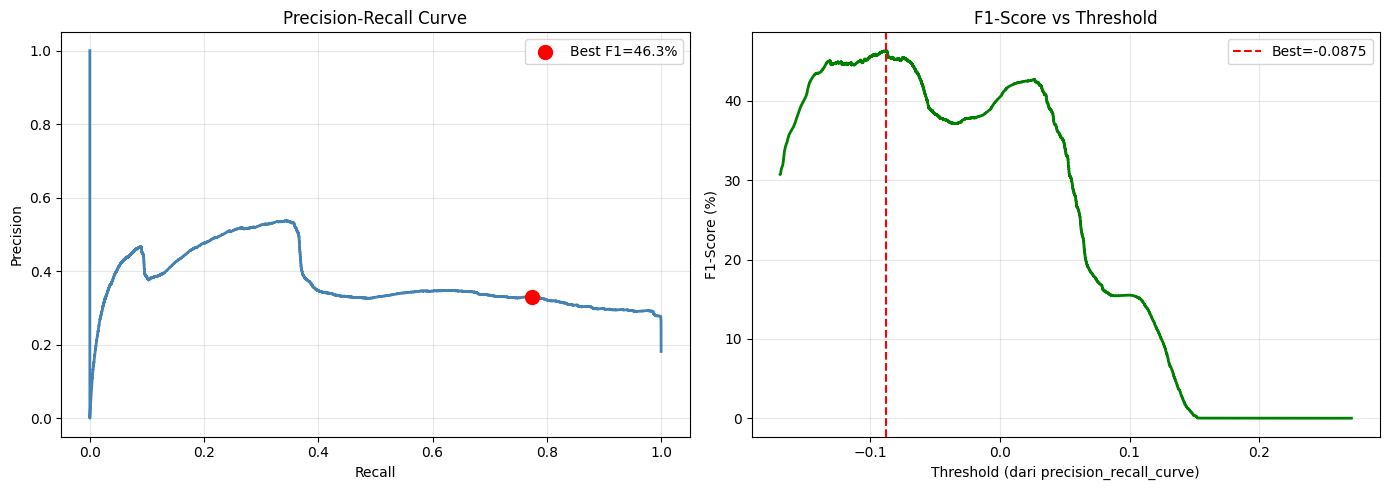


=== HASIL DENGAN THRESHOLD OPTIMAL ===
F1-Score  : 46.33%
Precision : 33.07%
Recall    : 77.37%
TP : 38,684 | FP : 78,305
TN : 147,064 | FN : 11,316


In [12]:
# ─── CELL BARU: Threshold Analysis ──────────────────────────
from sklearn.metrics import precision_recall_curve

# Hitung precision & recall di berbagai threshold
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, -anomaly_scores)

# Cari threshold dengan F1 terbaik
f1_scores_pr = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx      = np.argmax(f1_scores_pr)
best_thresh   = -thresholds_pr[best_idx]  # balik tanda karena kita pakai -anomaly_scores

print(f"Best F1 threshold : {best_thresh:.4f}")
print(f"Best F1           : {f1_scores_pr[best_idx]*100:.2f}%")
print(f"Precision at best : {precisions[best_idx]*100:.2f}%")
print(f"Recall at best    : {recalls[best_idx]*100:.2f}%")

# Plot Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[0].scatter(recalls[best_idx], precisions[best_idx], 
                color='red', s=100, zorder=5, label=f'Best F1={f1_scores_pr[best_idx]*100:.1f}%')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot F1 vs threshold
axes[1].plot(thresholds_pr, f1_scores_pr[:-1]*100, color='green', linewidth=2)
axes[1].axvline(x=-best_thresh, color='red', linestyle='--', label=f'Best={-best_thresh:.4f}')
axes[1].set_xlabel('Threshold (dari precision_recall_curve)')
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('F1-Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluasi ulang dengan threshold terbaik
y_pred_best = (anomaly_scores < best_thresh).astype(int)
f1_new  = f1_score(y_test, y_pred_best)
prec_new = precision_score(y_test, y_pred_best)
rec_new  = recall_score(y_test, y_pred_best)
cm_new  = confusion_matrix(y_test, y_pred_best)
tn2, fp2, fn2, tp2 = cm_new.ravel()

print(f"\n=== HASIL DENGAN THRESHOLD OPTIMAL ===")
print(f"F1-Score  : {f1_new*100:.2f}%")
print(f"Precision : {prec_new*100:.2f}%")
print(f"Recall    : {rec_new*100:.2f}%")
print(f"TP : {tp2:,} | FP : {fp2:,}")
print(f"TN : {tn2:,} | FN : {fn2:,}")

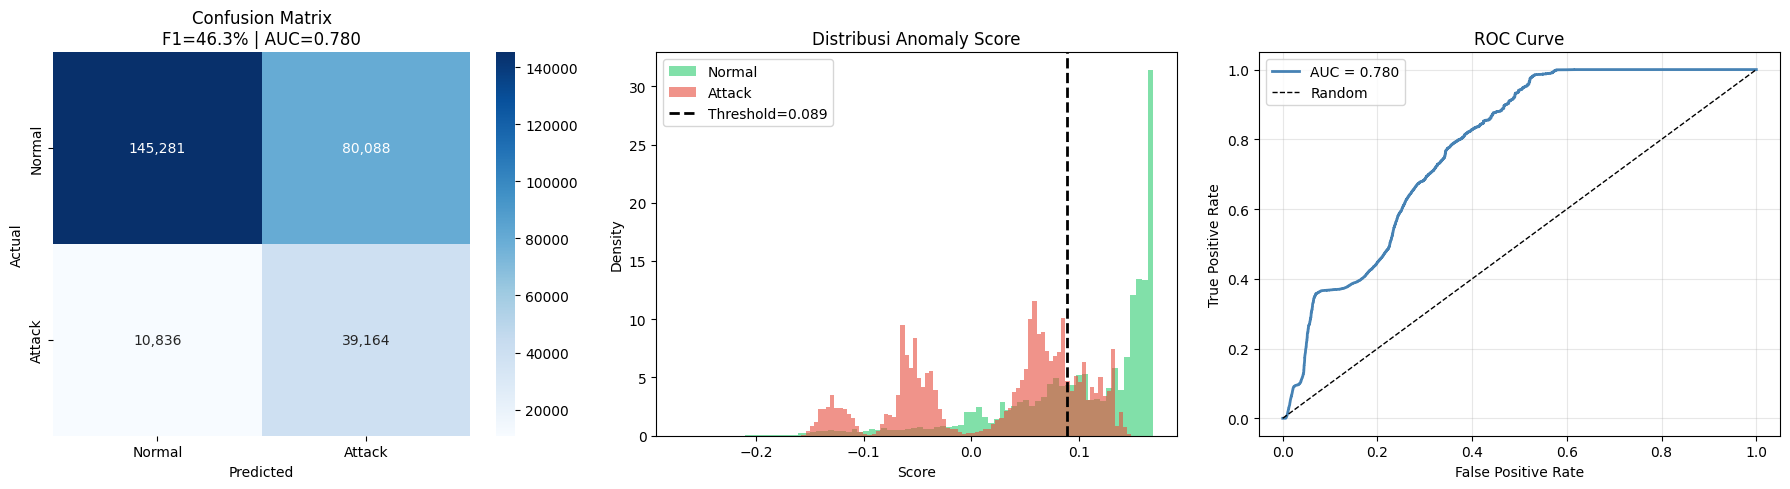

✅ Saved: model_evaluation_v3.png


In [9]:
# ─── CELL 9: Visualisasi Lengkap ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title(f'Confusion Matrix\nF1={f1*100:.1f}% | AUC={auc:.3f}', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: Anomaly Score Distribution
axes[1].hist(anomaly_scores[y_test==0], bins=80, alpha=0.6,
             color='#2ecc71', label='Normal', density=True)
axes[1].hist(anomaly_scores[y_test==1], bins=80, alpha=0.6,
             color='#e74c3c', label='Attack', density=True)
axes[1].axvline(x=best_threshold, color='black', linestyle='--',
                linewidth=2, label=f'Threshold={best_threshold:.3f}')
axes[1].set_title('Distribusi Anomaly Score', fontsize=12)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, -anomaly_scores)
axes[2].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
axes[2].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[2].set_title('ROC Curve', fontsize=12)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_evaluation_v3.png')

=== DETECTION RATE PER JENIS SERANGAN ===

⚠️ DDoS                : 18,263/28,309 (64.5%)
✅ FTP-Patator         : 1,233/1,248 (98.8%)
✅ PortScan            : 19,016/19,742 (96.3%)
✅ SSH-Patator         : 652/701 (93.0%)


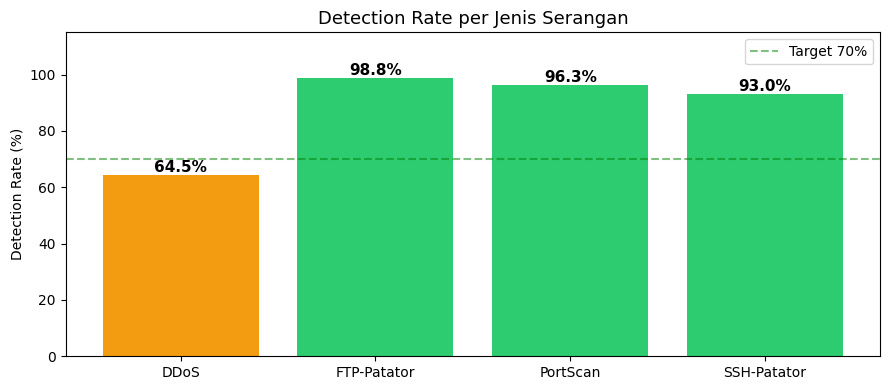

✅ Saved: detection_per_attack_v3.png


In [10]:
# ─── CELL 10: Detection Rate Per Jenis Serangan ──────────────
df_eval = X_test.copy()
df_eval['actual']        = y_test.values
df_eval['predicted']     = y_pred
df_eval['anomaly_score'] = anomaly_scores
df_eval['Label']         = df_test_combined['Label'].values

print('=== DETECTION RATE PER JENIS SERANGAN ===\n')
attack_results = {}
for attack_type in sorted(df_eval[df_eval['actual']==1]['Label'].unique()):
    subset   = df_eval[df_eval['Label'] == attack_type]
    detected = (subset['predicted'] == 1).sum()
    total    = len(subset)
    rate     = detected / total * 100
    attack_results[attack_type] = rate
    status = '✅' if rate >= 70 else '⚠️' if rate >= 40 else '❌'
    print(f'{status} {attack_type:20s}: {detected:,}/{total:,} ({rate:.1f}%)')

plt.figure(figsize=(9, 4))
colors_bar = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c'
              for v in attack_results.values()]
bars = plt.bar(attack_results.keys(), attack_results.values(), color=colors_bar)
plt.axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Target 70%')
plt.title('Detection Rate per Jenis Serangan', fontsize=13)
plt.ylabel('Detection Rate (%)')
plt.ylim(0, 115)
for bar, val in zip(bars, attack_results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('detection_per_attack_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: detection_per_attack_v3.png')

In [11]:
# ─── CELL 11: Simpan Model ───────────────────────────────────
model_file     = os.path.join(MODEL_PATH, 'isolation_forest.joblib')
scaler_file    = os.path.join(MODEL_PATH, 'scaler.joblib')
meta_file      = os.path.join(MODEL_PATH, 'model_meta.json')
threshold_file = os.path.join(MODEL_PATH, 'threshold.json')

joblib.dump(iso_forest, model_file)
joblib.dump(scaler,     scaler_file)

with open(threshold_file, 'w') as f:
    json.dump({'best_threshold': float(best_threshold)}, f, indent=2)

meta = {
    'model'          : 'IsolationForest',
    'strategy'       : 'semi-supervised (train on normal only)',
    'dataset'        : 'CICIDS 2017',
    'features'       : available,
    'n_features'     : len(available),
    'n_estimators'   : 300,
    'contamination'  : CONTAMINATION,
    'best_threshold' : float(best_threshold),
    'f1_score'       : round(f1, 4),
    'precision'      : round(precision, 4),
    'recall'         : round(recall, 4),
    'auc_roc'        : round(auc, 4),
    'train_samples'  : int(len(X_train)),
    'test_samples'   : int(len(X_test)),
    'attack_detection_rates': {k: round(v, 2) for k, v in attack_results.items()},
}
with open(meta_file, 'w') as f:
    json.dump(meta, f, indent=2)

model_mb = os.path.getsize(model_file)/1024/1024
print('✅ Model tersimpan!')
print(f'   isolation_forest.joblib ({model_mb:.1f} MB)')
print(f'   scaler.joblib')
print(f'   model_meta.json')
print(f'   threshold.json')
print(f'\n========== RINGKASAN AKHIR ==========')
print(f'Strategi   : Semi-supervised (train on normal only)')
print(f'Dataset    : CICIDS 2017')
print(f'Features   : {len(available)}')
print(f'Train size : {len(X_train):,} (normal only)')
print(f'Test size  : {len(X_test):,} (mixed)')
print(f'Threshold  : {best_threshold:.4f}')
print(f'F1-Score   : {f1*100:.2f}%')
print(f'Precision  : {precision*100:.2f}%')
print(f'Recall     : {recall*100:.2f}%')
print(f'AUC-ROC    : {auc:.4f}')
print(f'=====================================')

✅ Model tersimpan!
   isolation_forest.joblib (2.3 MB)
   scaler.joblib
   model_meta.json
   threshold.json

========== RINGKASAN AKHIR ==========
Strategi   : Semi-supervised (train on normal only)
Dataset    : CICIDS 2017
Features   : 25
Train size : 901,476 (normal only)
Test size  : 275,369 (mixed)
Threshold  : 0.0892
F1-Score   : 46.28%
Precision  : 32.84%
Recall     : 78.33%
AUC-ROC    : 0.7805


Training Random Forest...
(Estimasi 60-120 detik)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     20000
      Attack       1.00      1.00      1.00     45572

    accuracy                           1.00     65572
   macro avg       1.00      1.00      1.00     65572
weighted avg       1.00      1.00      1.00     65572

F1-Score  : 99.99%
Precision : 100.00%
Recall    : 99.98%
TP : 45,563 | FP : 0
TN : 20,000 | FN : 9

✅ Random Forest tersimpan!


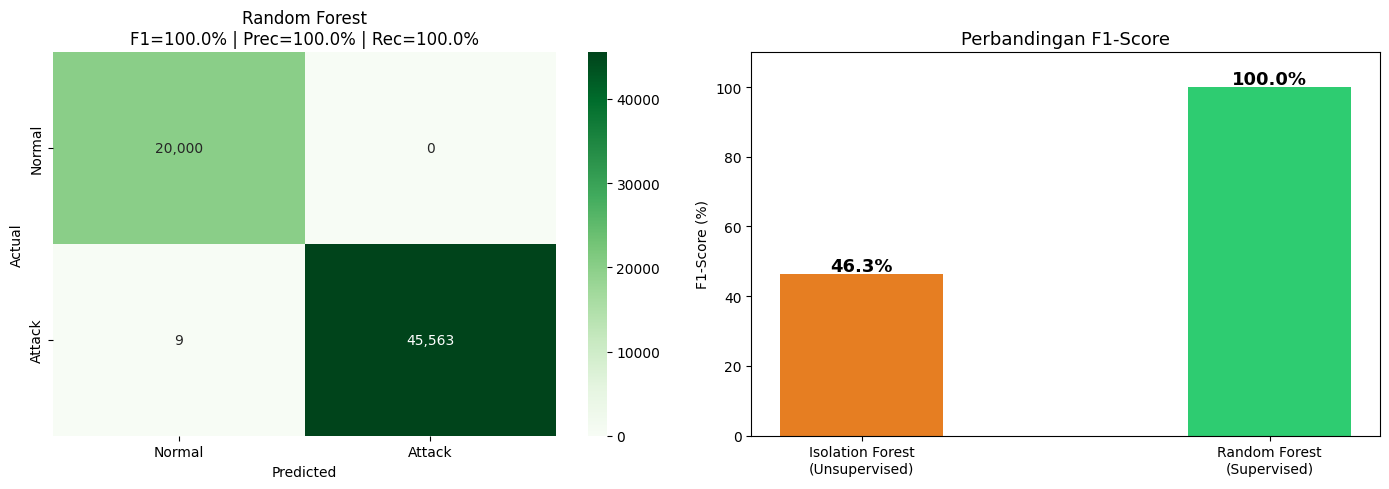

In [13]:
# ─── CELL BARU: Random Forest (Supervised) ───────────────────
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
print("(Estimasi 60-120 detik)\n")

# Untuk supervised: kita bisa pakai data berlabel (normal + attack)
df_supervised = pd.concat([
    df_clean[df_clean['is_attack']==0].sample(n=100_000, random_state=42),
    df_clean[df_clean['is_attack']==1]
]).sample(frac=1, random_state=42)

X_sup = df_supervised[available]
y_sup = df_supervised['is_attack']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sup, y_sup, test_size=0.2, random_state=42, stratify=y_sup
)

sc2 = StandardScaler()
X_tr_sc = sc2.fit_transform(X_tr)
X_te_sc  = sc2.transform(X_te)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf.fit(X_tr_sc, y_tr)

y_pred_rf = rf.predict(X_te_sc)
f1_rf  = f1_score(y_te, y_pred_rf)
prec_rf = precision_score(y_te, y_pred_rf)
rec_rf  = recall_score(y_te, y_pred_rf)
cm_rf  = confusion_matrix(y_te, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(classification_report(y_te, y_pred_rf, target_names=['Normal','Attack']))
print(f"F1-Score  : {f1_rf*100:.2f}%")
print(f"Precision : {prec_rf*100:.2f}%")
print(f"Recall    : {rec_rf*100:.2f}%")
print(f"TP : {tp_rf:,} | FP : {fp_rf:,}")
print(f"TN : {tn_rf:,} | FN : {fn_rf:,}")

# Simpan Random Forest juga
joblib.dump(rf,  os.path.join(MODEL_PATH, 'random_forest.joblib'))
joblib.dump(sc2, os.path.join(MODEL_PATH, 'scaler_rf.joblib'))
print("\n✅ Random Forest tersimpan!")

# Visualisasi perbandingan kedua model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix RF
sns.heatmap(cm_rf, annot=True, fmt=',', cmap='Greens', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title(f'Random Forest\nF1={f1_rf*100:.1f}% | Prec={prec_rf*100:.1f}% | Rec={rec_rf*100:.1f}%')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Perbandingan F1 kedua model
models  = ['Isolation Forest\n(Unsupervised)', 'Random Forest\n(Supervised)']
f1_vals = [46.28, f1_rf*100]
colors  = ['#e67e22', '#2ecc71']
bars = axes[1].bar(models, f1_vals, color=colors, width=0.4)
axes[1].set_title('Perbandingan F1-Score', fontsize=13)
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, f1_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()